# 504 reanálisis, 100 estudios, una pregunta incómoda

74%. Eso es lo que queda cuando le das los mismos datos a cinco personas distintas y les pides que respondan la misma pregunta. Tres de cada cuatro llegan a la misma conclusión que el estudio original. El otro cuarto... no.

> **Paper:** Kovács et al. (2025). *Investigating the analytical robustness of the social and behavioural sciences.* Nature.
> DOI: [10.1038/s41586-025-09844-9](https://doi.org/10.1038/s41586-025-09844-9)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-05-robustez-analitica-ciencias-sociales/notebook.ipynb)

[Pendiente]

## El experimento

Imagina que publicas un estudio y alguien más —con los mismos datos— decide analizarlos a su manera. ¿Llegaría a la misma conclusión?

El proyecto **Multi100** reclutó a 504 analistas para reanalizarlos: 100 estudios publicados entre 2009 y 2018 en ciencias sociales y del comportamiento. A cada estudio le asignaron entre 3 y 7 analistas independientes (mediana: 5). Les dieron los datos originales y les dijeron qué pregunta responder — pero el método lo eligió cada quien.

Los 100 estudios abarcan 8 disciplinas — dominan ciencia política (37) y economía (30), seguidas de psicología (17) y sociología (8). Dos tercios son observacionales.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TOLERANCIA_ESTRECHA = 0.05    # ±0,05 Cohen's d (tolerancia del paper)
TOLERANCIA_AMPLIA = 0.20      # ±0,20 Cohen's d (4× más amplia)
FUENTE = 'Fuente: Kovács et al. (2025), Nature | Datos: github.com/marton-balazs-kovacs/multi100'
COLOR_MISMA = '#2563EB'       # Azul CaM — misma conclusión
COLOR_SIN_EFECTO = '#D97706'  # Amber — sin efecto / inconcluso
COLOR_OPUESTO = '#DC2626'     # Rojo — efecto opuesto
COLOR_IDENTIDAD = '#BBBBBB'   # Gris — línea de identidad

# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# Datos
BASE_URL = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-04-05-robustez-analitica-ciencias-sociales'
for f in ['efectos_original_vs_reanalisis.csv', 'robustez_por_paper.csv', 'conclusiones_por_disciplina.csv']:
    if not os.path.exists(f'datos/{f}'):
        os.makedirs('datos', exist_ok=True)
        urllib.request.urlretrieve(f'{BASE_URL}/datos/{f}', f'datos/{f}')

df = pd.read_csv('datos/efectos_original_vs_reanalisis.csv')
papers = pd.read_csv('datos/robustez_por_paper.csv')
disc = pd.read_csv('datos/conclusiones_por_disciplina.csv')

print(f'Reanálisis cargados: {len(df)}')
print(f'Papers: {len(papers)}')
print(f'Disciplinas: {len(disc)}')
print(f'Conclusiones: {df["conclusion"].value_counts().to_dict()}')

Reanálisis cargados: 504
Papers: 100
Disciplinas: 8
Conclusiones: {'misma': 371, 'sin_efecto': 122, 'opuesto': 11}


## ¿Cuánto cambia el resultado?

Cada punto es un reanálisis. Si todos llegaran al mismo resultado, caerían sobre la diagonal.

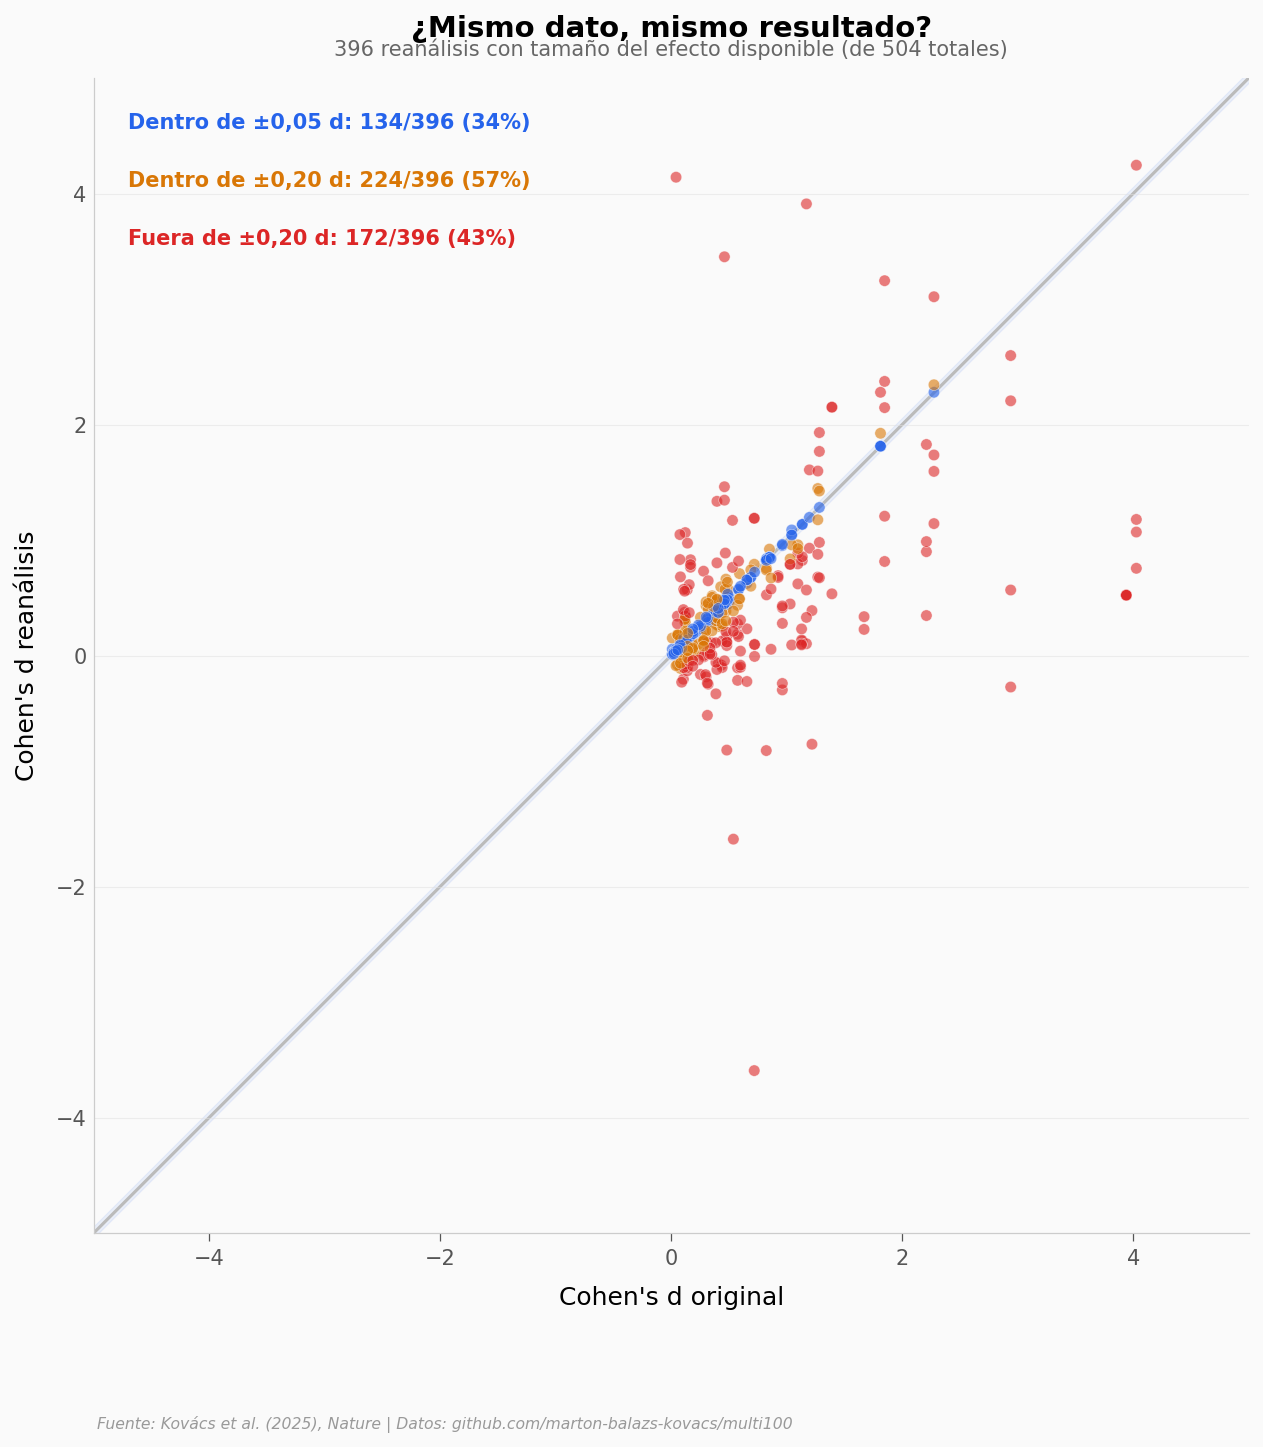

In [2]:
# Gráfica hero: efecto original vs reanálisis
paired = df.dropna(subset=['d_original', 'd_reanalisis']).copy()
paired['d_diff_abs'] = (paired['d_reanalisis'] - paired['d_original']).abs()

fig, ax = plt.subplots(figsize=(10, 10))

# Línea de identidad
lim = max(abs(paired['d_original']).max(), abs(paired['d_reanalisis']).max()) * 1.1
ax.plot([-lim, lim], [-lim, lim], color=COLOR_IDENTIDAD, linewidth=1.5, zorder=1, label='_')

# Banda de tolerancia ±0.05
x_line = np.linspace(-lim, lim, 100)
ax.fill_between(x_line, x_line - TOLERANCIA_ESTRECHA, x_line + TOLERANCIA_ESTRECHA,
                color=COLOR_MISMA, alpha=0.08, zorder=0)

# Colorear por proximidad
colors = []
for _, row in paired.iterrows():
    if row['d_diff_abs'] <= TOLERANCIA_ESTRECHA:
        colors.append(COLOR_MISMA)
    elif row['d_diff_abs'] <= TOLERANCIA_AMPLIA:
        colors.append(COLOR_SIN_EFECTO)
    else:
        colors.append(COLOR_OPUESTO)

ax.scatter(paired['d_original'], paired['d_reanalisis'],
           c=colors, s=30, alpha=0.6, edgecolors='white', linewidths=0.3, zorder=5)

# Anotaciones
n_total = len(paired)
n_005 = (paired['d_diff_abs'] <= TOLERANCIA_ESTRECHA).sum()
n_020 = (paired['d_diff_abs'] <= TOLERANCIA_AMPLIA).sum()

ax.text(0.03, 0.97, f'Dentro de ±0,05 d: {n_005}/{n_total} ({n_005/n_total*100:.0f}%)',
        transform=ax.transAxes, fontsize=10, color=COLOR_MISMA, fontweight='bold', va='top')
ax.text(0.03, 0.92, f'Dentro de ±0,20 d: {n_020}/{n_total} ({n_020/n_total*100:.0f}%)',
        transform=ax.transAxes, fontsize=10, color=COLOR_SIN_EFECTO, fontweight='bold', va='top')
ax.text(0.03, 0.87, f'Fuera de ±0,20 d: {n_total - n_020}/{n_total} ({(n_total - n_020)/n_total*100:.0f}%)',
        transform=ax.transAxes, fontsize=10, color=COLOR_OPUESTO, fontweight='bold', va='top')

ax.set_xlabel("Cohen's d original", fontsize=12)
ax.set_ylabel("Cohen's d reanálisis", fontsize=12)
ax.set_title('¿Mismo dato, mismo resultado?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, '396 reanálisis con tamaño del efecto disponible (de 504 totales)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Limitar ejes para legibilidad (excluir outliers extremos)
clip = 5
ax.set_xlim(-clip, clip)
ax.set_ylim(-clip, clip)
ax.set_aspect('equal')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_original_vs_reanalisis.png', dpi=200, bbox_inches='tight')
plt.show()

La banda azul marca la zona de tolerancia estrecha (±0,05 en Cohen's d). Solo el 34% de los reanálisis caen ahí — es decir, producen un resultado prácticamente idéntico al original.

Si ampliamos la tolerancia cuatro veces (±0,20 d), llegamos al 57%. Pero el 43% restante obtiene un tamaño del efecto que difiere en más de 0,20 puntos de d. En ciencias sociales, 0,20 es la diferencia entre "efecto pequeño" y "no hay efecto".

Ojo: la correlación entre efectos originales y reanalizados es moderada (Spearman ρ = 0,57 — mide qué tan bien se mantiene el orden relativo de los efectos; p < 0,001, n = 396). Los reanálisis no son ruido aleatorio — van en la misma dirección general —, pero la magnitud varía mucho.

## ¿Hay disciplinas más robustas?

La conclusión (no solo el número) es lo que importa: ¿el reanálisis apoya, contradice, o no encuentra el efecto del estudio original?

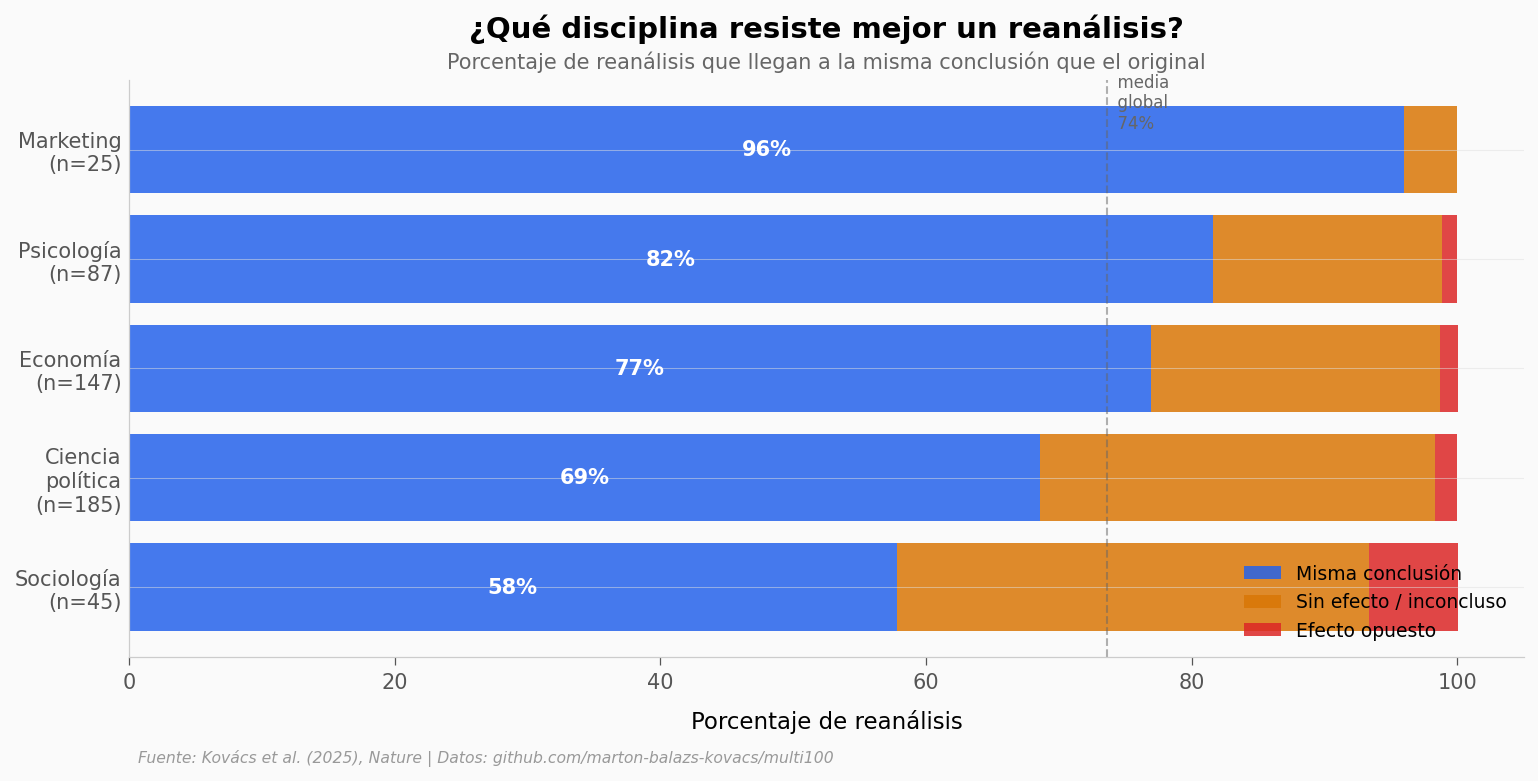

In [3]:
# Conclusiones por disciplina (solo disciplinas con n ≥ 20)
disc_plot = disc[disc['n_reanalisis'] >= 20].sort_values('pct_misma', ascending=True).copy()

nombres = {
    'ciencia_politica': 'Ciencia\npolítica',
    'economia': 'Economía',
    'psicologia': 'Psicología',
    'sociologia': 'Sociología',
    'marketing': 'Marketing'
}
disc_plot['nombre'] = disc_plot['disciplina'].map(nombres)
disc_plot['pct_sin_efecto'] = disc_plot['n_sin_efecto'] / disc_plot['n_reanalisis'] * 100
disc_plot['pct_opuesto'] = disc_plot['n_opuesto'] / disc_plot['n_reanalisis'] * 100

fig, ax = plt.subplots(figsize=(12, 5))

y_pos = range(len(disc_plot))
bars_misma = ax.barh(y_pos, disc_plot['pct_misma'], color=COLOR_MISMA, alpha=0.85, label='Misma conclusión')
bars_sin = ax.barh(y_pos, disc_plot['pct_sin_efecto'], left=disc_plot['pct_misma'],
                   color=COLOR_SIN_EFECTO, alpha=0.85, label='Sin efecto / inconcluso')
bars_op = ax.barh(y_pos, disc_plot['pct_opuesto'],
                  left=disc_plot['pct_misma'] + disc_plot['pct_sin_efecto'],
                  color=COLOR_OPUESTO, alpha=0.85, label='Efecto opuesto')

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row['nombre']}\n(n={row['n_reanalisis']:.0f})" for _, row in disc_plot.iterrows()],
                   fontsize=10)
ax.set_xlabel('Porcentaje de reanálisis', fontsize=11)
ax.set_xlim(0, 105)

# Inline labels
for i, (_, row) in enumerate(disc_plot.iterrows()):
    ax.text(row['pct_misma'] / 2, i, f"{row['pct_misma']:.0f}%",
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')

ax.axvline(x=73.6, color='#666666', linewidth=1, linestyle='--', alpha=0.5)
ax.text(73.6, len(disc_plot) - 0.3, '  media\n  global\n  74%',
        fontsize=8, color='#666666', va='top')

ax.legend(fontsize=9, loc='lower right', framealpha=0.9)

ax.set_title('¿Qué disciplina resiste mejor un reanálisis?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Porcentaje de reanálisis que llegan a la misma conclusión que el original',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/conclusiones_por_disciplina.png', dpi=200, bbox_inches='tight')
plt.show()

Marketing lidera con un 96% de acuerdo (n = 25), seguida de psicología (82%), economía (77%) y ciencia política (69%). Sociología baja al 58%.

Pero las disciplinas no son la única variable. ¿Importa si el estudio original encontró un efecto grande o pequeño? Intuitivamente, un efecto enorme debería ser fácil de replicar. Veamos si los datos lo confirman.

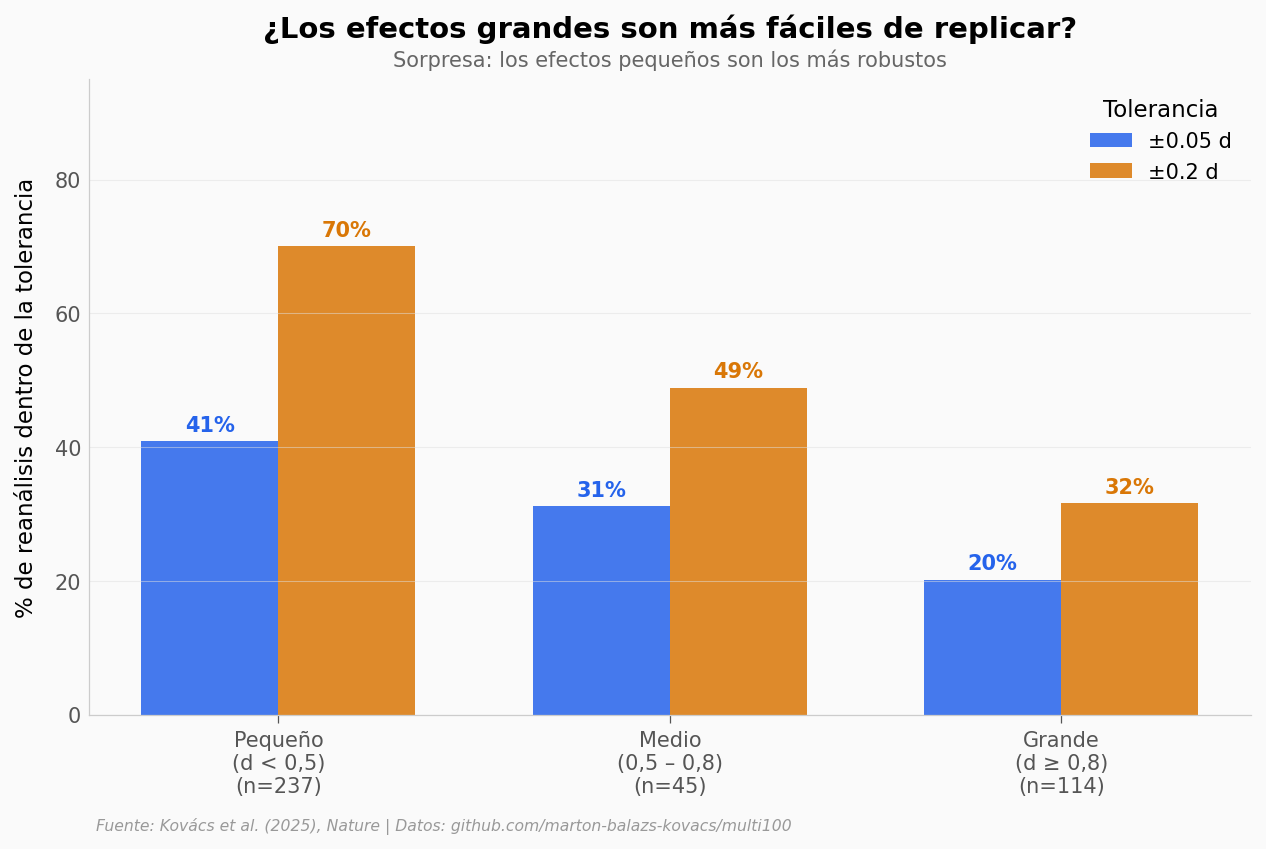

In [4]:
# Robustez por tamaño del efecto original
paired2 = paired.copy()
paired2['d_orig_abs'] = paired2['d_original'].abs()

bins = [0, 0.5, 0.8, 100]
labels = ['Pequeño\n(d < 0,5)', 'Medio\n(0,5 – 0,8)', 'Grande\n(d ≥ 0,8)']
paired2['size_cat'] = pd.cut(paired2['d_orig_abs'], bins=bins, labels=labels, right=False)

rob_by_size = paired2.groupby('size_cat', observed=True).agg(
    n=('d_diff_abs', 'count'),
    pct_005=('d_diff_abs', lambda x: (x <= TOLERANCIA_ESTRECHA).mean() * 100),
    pct_020=('d_diff_abs', lambda x: (x <= TOLERANCIA_AMPLIA).mean() * 100)
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5.5))

x = np.arange(len(rob_by_size))
width = 0.35

bars1 = ax.bar(x - width/2, rob_by_size['pct_005'], width,
               color=COLOR_MISMA, alpha=0.85, label=f'±{TOLERANCIA_ESTRECHA} d')
bars2 = ax.bar(x + width/2, rob_by_size['pct_020'], width,
               color=COLOR_SIN_EFECTO, alpha=0.85, label=f'±{TOLERANCIA_AMPLIA} d')

# Labels sobre barras
for bar, val in zip(bars1, rob_by_size['pct_005']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.0f}%', ha='center', fontsize=10, fontweight='bold', color=COLOR_MISMA)
for bar, val in zip(bars2, rob_by_size['pct_020']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.0f}%', ha='center', fontsize=10, fontweight='bold', color=COLOR_SIN_EFECTO)

ax.set_xticks(x)
ax.set_xticklabels([f"{row['size_cat']}\n(n={row['n']:.0f})" for _, row in rob_by_size.iterrows()],
                   fontsize=10)
ax.set_ylabel('% de reanálisis dentro de la tolerancia', fontsize=11)
ax.set_ylim(0, 95)

ax.legend(fontsize=10, loc='upper right', framealpha=0.9, title='Tolerancia')

ax.set_title('¿Los efectos grandes son más fáciles de replicar?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Sorpresa: los efectos pequeños son los más robustos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/robustez_por_efecto.png', dpi=200, bbox_inches='tight')
plt.show()

Contra la intuición: los efectos pequeños (d < 0,5) son los más robustos. Un 41% cae dentro de ±0,05 d, frente a solo el 20% de los efectos grandes.

¿Por qué? Los efectos grandes suelen depender de decisiones analíticas más específicas (qué covariables incluir, cómo manejar outliers). Los pequeños, al ser más cercanos a cero, varían menos en términos absolutos.

## ¿Cuántos estudios resisten por completo?

Pasemos del reanálisis individual al nivel del estudio: ¿en cuántos papers TODOS los analistas coincidieron?

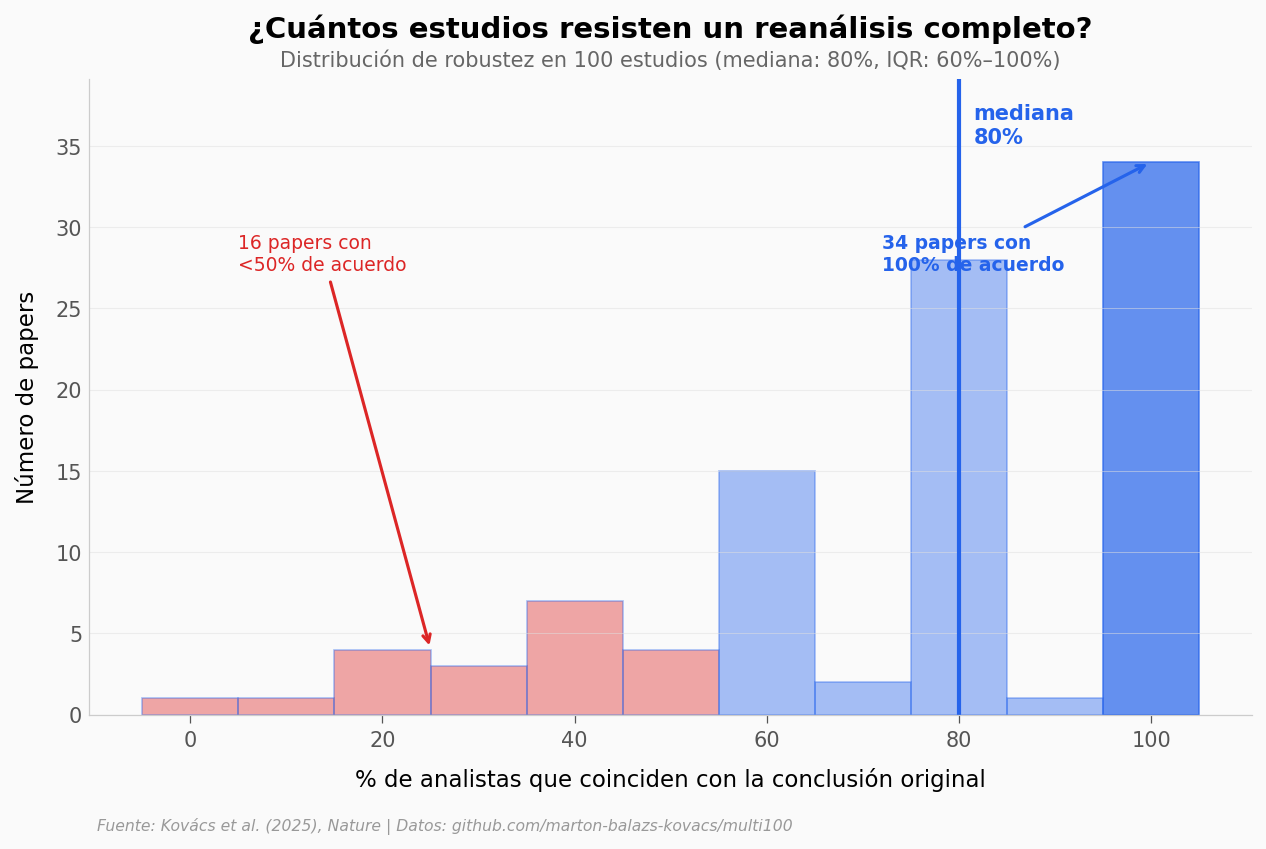

In [5]:
# Histograma: robustez por paper
fig, ax = plt.subplots(figsize=(10, 5.5))

n_bins, bins, patches = ax.hist(papers['pct_misma'], bins=np.arange(-5, 115, 10),
                                 color=COLOR_MISMA, alpha=0.4,
                                 edgecolor=COLOR_MISMA, linewidth=0.8)

# Colorear bin extremos
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge >= 95:
        patch.set_facecolor(COLOR_MISMA)
        patch.set_alpha(0.7)
    elif left_edge < 50:
        patch.set_facecolor(COLOR_OPUESTO)
        patch.set_alpha(0.4)

# Media y mediana
media = papers['pct_misma'].mean()
mediana = papers['pct_misma'].median()
y_max = n_bins.max() * 1.15
ax.set_ylim(0, y_max)

ax.axvline(x=mediana, color=COLOR_MISMA, linewidth=2, linestyle='-')
ax.text(mediana + 1.5, y_max * 0.9, f'mediana\n{mediana:.0f}%',
        fontsize=10, color=COLOR_MISMA, fontweight='bold')

# Zona de bajo consenso
n_bajo = (papers['pct_misma'] < 50).sum()
ax.annotate(f'{n_bajo} papers con\n<50% de acuerdo',
            xy=(25, n_bins[2] if len(n_bins) > 2 else 1),
            xytext=(5, y_max * 0.7),
            fontsize=9, color=COLOR_OPUESTO,
            arrowprops=dict(arrowstyle='->', color=COLOR_OPUESTO, lw=1.5))

# Papers 100% robustos
n_100 = (papers['pct_misma'] == 100).sum()
ax.annotate(f'{n_100} papers con\n100% de acuerdo',
            xy=(100, n_bins[-1]),
            xytext=(72, y_max * 0.7),
            fontsize=9, color=COLOR_MISMA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_MISMA, lw=1.5))

ax.set_xlabel('% de analistas que coinciden con la conclusión original', fontsize=11)
ax.set_ylabel('Número de papers', fontsize=11)
ax.set_title('¿Cuántos estudios resisten un reanálisis completo?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'Distribución de robustez en 100 estudios (mediana: {mediana:.0f}%, IQR: {papers["pct_misma"].quantile(0.25):.0f}%–{papers["pct_misma"].quantile(0.75):.0f}%)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_robustez.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El 34% de los reanálisis coinciden con el original dentro de ±0,05 d | ✅ | Nuestro cálculo: 33,8% (134/396). Cross-check: <1% de diferencia con el paper |
| Con tolerancia 4× más amplia (±0,20), sube al 57% | ✅ | Nuestro cálculo: 56,6% (224/396). Cross-check: <1% |
| El 74% llegan a la misma conclusión cualitativa | ✅ | Nuestro cálculo: 73,6% (371/504). Cada analista categorizó su propia conclusión |
| Solo el 2% reportan un efecto opuesto al original | ✅ | Nuestro cálculo: 2,2% (11/504). El 24% restante es "sin efecto / inconcluso" |
| Los efectos pequeños son más robustos que los grandes | ✅ | d < 0,5: 41% dentro de ±0,05; d ≥ 0,8: 20%. Patrón consistente |
| Los estudios experimentales son más robustos que los observacionales | ✅ | Experimental: 44% dentro de ±0,05 d; Observacional: 28% |

> **Limitaciones:** (1) Los 100 estudios son una muestra estratificada, no aleatoria — dominan ciencia política y economía. (2) Cada estudio tiene 3–7 analistas; con más analistas por estudio, la variabilidad podría ser mayor. (3) El propio paper lo describe como estudio **exploratorio** — los patrones son informativos pero no confirman un modelo causal. (4) Los datos del repositorio son una versión viva que puede diferir ligeramente del paper publicado.

## Ahora tú

1. **¿La experiencia importa?** Los analistas reportaron sus años de experiencia. ¿Los más experimentados coinciden más con el original? (Pista: cruza con `years_of_experience` del dataset completo en GitHub)

2. **¿Qué pasa si separamos por diseño?** En la celda de abajo puedes comparar estudios experimentales vs observacionales con la gráfica hero. ¿Cuál muestra menos dispersión?

3. **¿Hay papers "frágiles"?** De los 16 papers con menos del 50% de acuerdo, ¿hay algún patrón en su disciplina o tamaño del efecto?

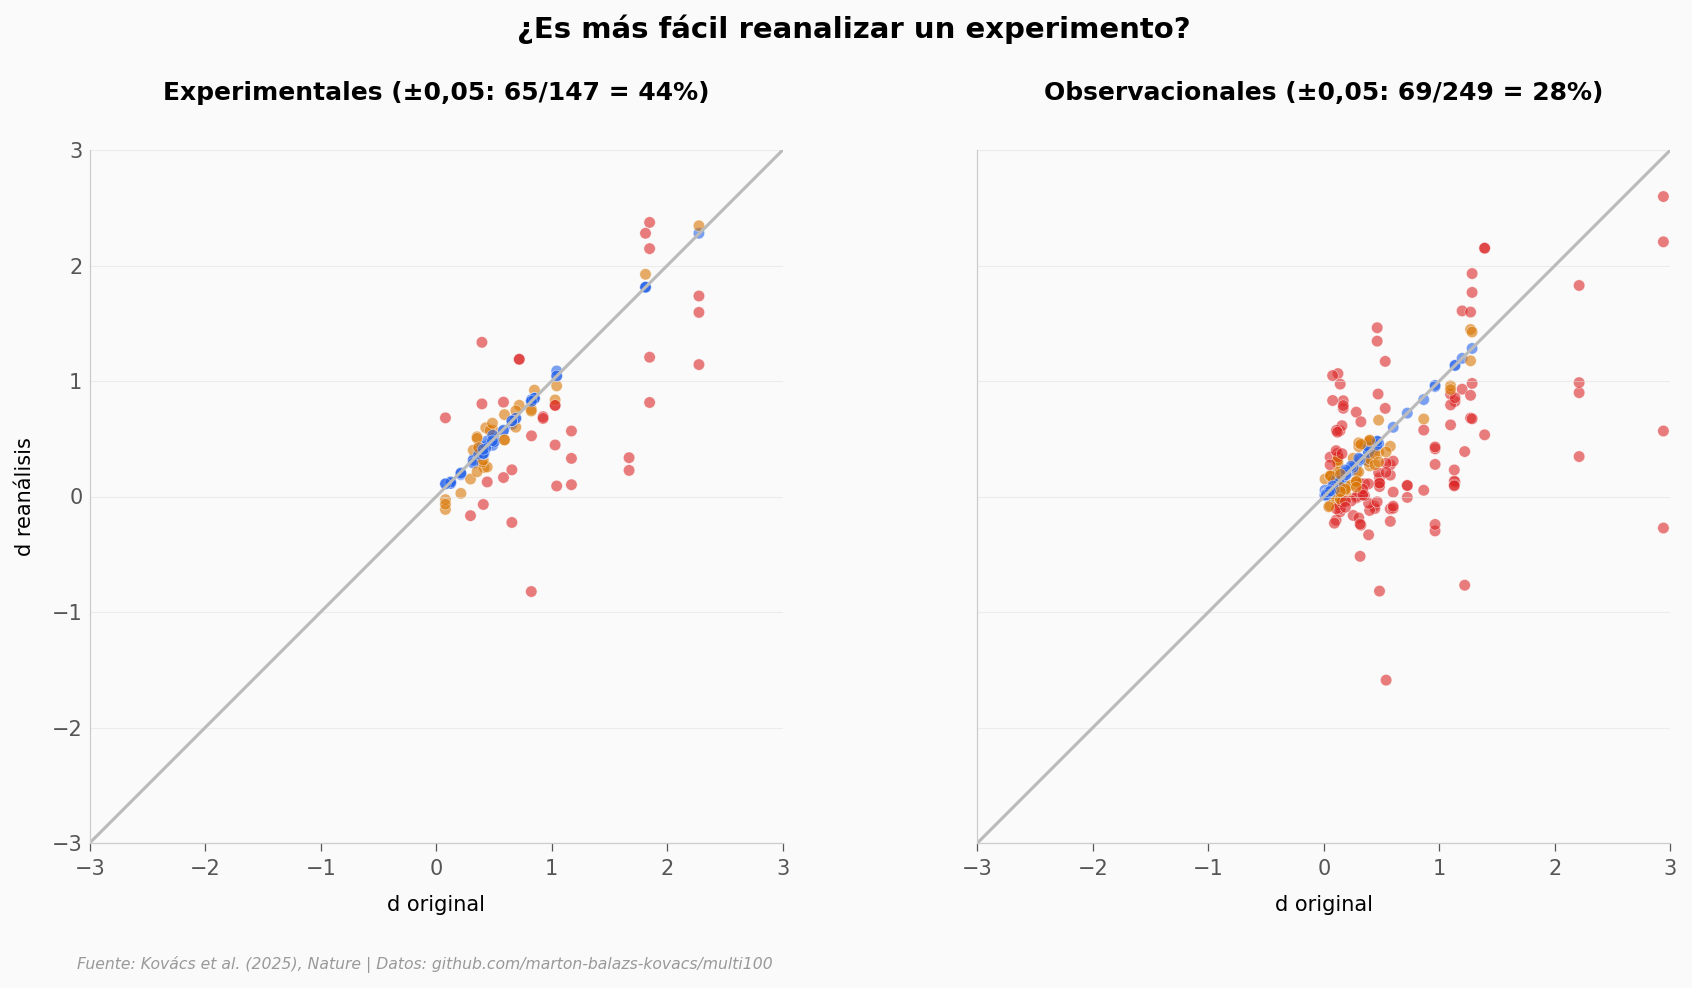

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Compara experimental vs observacional en la gráfica de dispersión
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, (design, label) in zip(axes, [(1, 'Experimentales'), (0, 'Observacionales')]):
    sub = paired[paired['d_original'].isin(
        papers[papers['experimental'] == design]['d_original']
    )].copy()
    # Fallback: merge por paper_id si el filtro directo no funciona
    if len(sub) < 10:
        exp_papers = set(papers[papers['experimental'] == design]['paper_id'])
        sub = paired[paired['paper_id'].isin(exp_papers)].copy()

    sub['d_diff_abs'] = (sub['d_reanalisis'] - sub['d_original']).abs()
    colors = [COLOR_MISMA if d <= TOLERANCIA_ESTRECHA
              else COLOR_SIN_EFECTO if d <= TOLERANCIA_AMPLIA
              else COLOR_OPUESTO for d in sub['d_diff_abs']]

    ax.plot([-5, 5], [-5, 5], color=COLOR_IDENTIDAD, linewidth=1.5)
    ax.scatter(sub['d_original'], sub['d_reanalisis'], c=colors,
               s=30, alpha=0.6, edgecolors='white', linewidths=0.3)

    n_005 = (sub['d_diff_abs'] <= TOLERANCIA_ESTRECHA).sum()
    ax.set_title(f'{label} (±0,05: {n_005}/{len(sub)} = {n_005/len(sub)*100:.0f}%)',
                 fontsize=12, fontweight='bold')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.set_xlabel("d original", fontsize=10)

axes[0].set_ylabel("d reanálisis", fontsize=10)

fig.suptitle('¿Es más fácil reanalizar un experimento?', fontsize=14, fontweight='bold', y=1.03)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/experimental_vs_observacional.png', dpi=200, bbox_inches='tight')
plt.show()

---

**Paper:** Kovács et al. (2025). *Investigating the analytical robustness of the social and behavioural sciences.* Nature. DOI: [10.1038/s41586-025-09844-9](https://doi.org/10.1038/s41586-025-09844-9)

**Datos:** [github.com/marton-balazs-kovacs/multi100](https://github.com/marton-balazs-kovacs/multi100) — archivos procesados del proyecto Multi100 (MIT License)

**Notebook:** [Ciencia a Mordiscos — El Lab](https://cienciaamordiscos.com) | [Repositorio](https://github.com/Ciencia-a-Mordiscos/lab)